In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings


In [2]:
warnings.filterwarnings("ignore")

In [3]:
WINDOWS_LOG   = "windows_event_logs.csv"
ZEEK_LOG      = "zeek_conn_logs.csv"
RANDOM_STATE  = 42
TOP_N         = 20     # how many top threats to print


In [4]:
print("=" * 60)
print("  GIBL Threat Agent — Random Forest")
print("=" * 60)

  GIBL Threat Agent — Random Forest


In [5]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
print("\n[1] Loading data...")
win = pd.read_csv(WINDOWS_LOG)
zeek = pd.read_csv(ZEEK_LOG)
print(f"    Windows events : {len(win):,} rows")
print(f"    Zeek conn logs : {len(zeek):,} rows")


[1] Loading data...
    Windows events : 800,000 rows
    Zeek conn logs : 1,000,000 rows


## 1b. Session grouping (IP + 15-min activity gap)

Grouping by `source_ip` alone collapses every event for a chatty IP into a single row, which is what was causing the imbalance. Instead we split each IP's events into **sessions**: a new session starts whenever the gap since that IP's previous event exceeds `SESSION_GAP_MINUTES` (15 min). Consecutive bursts of activity from the same IP stay together as one session, but activity that resumes after a long quiet period is treated as a separate session.

In [6]:
SESSION_GAP_MINUTES = 15

def assign_session_id(df, ip_col, ts_col, gap_minutes=SESSION_GAP_MINUTES, out_col="session_id"):
    """
    Assigns a session_id to each row such that rows sharing the same ip_col
    AND occurring within `gap_minutes` of the previous event (for that same IP)
    belong to the same session. A new session starts whenever the gap since
    that IP's previous event exceeds gap_minutes.

    Returns a copy sorted by [ip_col, ts_col] with the new session_id column added.
    """
    out = df.sort_values([ip_col, ts_col]).copy()
    gap = pd.Timedelta(minutes=gap_minutes)

    time_delta = out.groupby(ip_col)[ts_col].diff()
    new_session = (time_delta.isna()) | (time_delta > gap)

    out["_session_seq"] = new_session.groupby(out[ip_col]).cumsum()
    out[out_col] = out[ip_col].astype(str) + "_" + out["_session_seq"].astype(int).astype(str)
    out = out.drop(columns=["_session_seq"])
    return out


In [7]:
# ── 2. WINDOWS FEATURES ──────────────────────────────────────────────────────
print("\n[2] Engineering Windows behavioral features...")
 
win["timestamp"] = pd.to_datetime(win["timestamp"])
win["source_ip"] = win["source_ip"].fillna("LOCAL")


[2] Engineering Windows behavioral features...


In [8]:
# Behavioral event-type flags (continuous counts, not binary labels)
win["is_failed_logon"]      = (win["event_id"] == 4625).astype(int)
win["is_process_create"]    = (win["event_id"] == 4688).astype(int)
win["is_privileged_logon"]  = (win["event_id"] == 4672).astype(int)
win["is_service_install"]   = (win["event_id"] == 7045).astype(int)
win["is_rdp_logon"]         = (win["logon_type"] == 10).astype(int)
win["is_network_logon"]     = (win["logon_type"] == 3).astype(int)

In [9]:
# Off-hours: computed relative to dataset's own activity distribution
#   Rather than assuming 8-18 is "normal", we find the hours that cover
#   the busiest 50% of all activity and treat the rest as off-hours.
hour_counts  = win["timestamp"].dt.hour.value_counts().sort_index()
busy_hours   = set(hour_counts[hour_counts >= hour_counts.median()].index)
win["is_off_hours"] = (~win["timestamp"].dt.hour.isin(busy_hours)).astype(int)

In [10]:
win = assign_session_id(win, ip_col="source_ip", ts_col="timestamp")

win_feat = win.groupby(["source_ip", "session_id"]).agg(
    win_session_start      = ("timestamp",            "min"),
    win_total_events       = ("event_log_id",        "count"),
    win_unique_hosts       = ("hostname",             "nunique"),
    win_unique_users       = ("subject_username",     "nunique"),
    win_failed_logons      = ("is_failed_logon",      "sum"),
    win_process_creations  = ("is_process_create",    "sum"),
    win_privileged_logons  = ("is_privileged_logon",  "sum"),
    win_service_installs   = ("is_service_install",   "sum"),
    win_rdp_logons         = ("is_rdp_logon",         "sum"),
    win_network_logons     = ("is_network_logon",     "sum"),
    win_off_hours_events   = ("is_off_hours",         "sum"),
).reset_index()

In [11]:
# Ratio features normalise for volume — a busy server with 5 fails looks
# very different to an IP with 5 events all of which are fails.
n = win_feat["win_total_events"].clip(lower=1)
win_feat["win_fail_ratio"]       = win_feat["win_failed_logons"]     / n
win_feat["win_priv_ratio"]       = win_feat["win_privileged_logons"] / n
win_feat["win_process_ratio"]    = win_feat["win_process_creations"] / n
win_feat["win_off_hours_ratio"]  = win_feat["win_off_hours_events"]  / n
 
print(f"    → {len(win_feat):,} unique source IPs")

    → 795,000 unique source IPs


In [12]:
# ── 3. ZEEK FEATURES ─────────────────────────────────────────────────────────
print("\n[3] Engineering Zeek behavioral features...")
 
zeek["ts"] = pd.to_datetime(zeek["ts"])
 



[3] Engineering Zeek behavioral features...


In [13]:
# Continuous behavioral descriptors — no hardcoded port/hash assumptions
zeek["is_off_hours"]    = (~zeek["ts"].dt.hour.isin(busy_hours)).astype(int)
zeek["is_failed_conn"]  = (zeek["conn_state"].isin(["S0", "REJ"])).astype(int)
zeek["is_encrypted"]    = zeek["service"].isin(["ssl", "tls"]).astype(int)
zeek["bytes_ratio"]     = zeek["orig_bytes"] / zeek["resp_bytes"].clip(lower=1)
 
zeek = assign_session_id(zeek, ip_col="id_orig_h", ts_col="ts")

zeek_feat = zeek.groupby(["id_orig_h", "session_id"]).agg(
    zeek_session_start     = ("ts",           "min"),
    zeek_total_conns       = ("log_id",       "count"),
    zeek_unique_dst_ips    = ("id_resp_h",    "nunique"),
    zeek_unique_dst_ports  = ("id_resp_p",    "nunique"),
    zeek_failed_conns      = ("is_failed_conn","sum"),
    zeek_encrypted_conns   = ("is_encrypted", "sum"),
    zeek_off_hours_conns   = ("is_off_hours", "sum"),
    zeek_mean_duration     = ("duration",     "mean"),
    zeek_mean_orig_bytes   = ("orig_bytes",   "mean"),
    zeek_mean_resp_bytes   = ("resp_bytes",   "mean"),
    zeek_total_orig_bytes  = ("orig_bytes",   "sum"),
    zeek_mean_bytes_ratio  = ("bytes_ratio",  "mean"),
    zeek_mean_orig_pkts    = ("orig_pkts",    "mean"),
).reset_index().rename(columns={"id_orig_h": "source_ip"})
 
n = zeek_feat["zeek_total_conns"].clip(lower=1)
zeek_feat["zeek_fail_ratio"]       = zeek_feat["zeek_failed_conns"]    / n
zeek_feat["zeek_encrypted_ratio"]  = zeek_feat["zeek_encrypted_conns"] / n
zeek_feat["zeek_off_hours_ratio"]  = zeek_feat["zeek_off_hours_conns"] / n
zeek_feat["zeek_dst_diversity"]    = zeek_feat["zeek_unique_dst_ports"] / zeek_feat["zeek_unique_dst_ips"].clip(lower=1)
 
print(f"    → {len(zeek_feat):,} unique source IPs")

    → 993,859 unique source IPs


In [14]:
# ── 4. MERGE ─────────────────────────────────────────────────────────────────
print("\n[4] Merging feature tables (session-aligned)...")

# win_feat and zeek_feat are now one row PER SESSION per IP, not one row per IP.
# Their session_id values come from independent event streams (Windows logs vs
# Zeek conn logs), so they won't line up as strings — instead we align sessions
# that belong to the same IP and whose session_start times fall within the same
# 15-minute window, using merge_asof (nearest match, capped at the gap size).

win_sorted  = win_feat.sort_values("win_session_start")
zeek_sorted = zeek_feat.sort_values("zeek_session_start")

combined = pd.merge_asof(
    win_sorted,
    zeek_sorted,
    left_on="win_session_start",
    right_on="zeek_session_start",
    by="source_ip",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=SESSION_GAP_MINUTES),
)

# Any Zeek sessions that found no Windows counterpart within tolerance are
# dropped by merge_asof (it only walks the left/win side). Add those back as
# their own rows so we still get a full outer union of sessions, same as the
# original how="outer" merge did at the IP level.
matched_zeek_keys = set(
    zip(combined["source_ip"], combined["zeek_session_start"])
)
unmatched_zeek = zeek_sorted[
    ~zeek_sorted.apply(lambda r: (r["source_ip"], r["zeek_session_start"]) in matched_zeek_keys, axis=1)
]
combined = pd.concat([combined, unmatched_zeek], ignore_index=True).fillna(0)

print(f"    -> {len(combined):,} IP-sessions with combined features "
      f"(was {win_feat['source_ip'].nunique() if False else combined['source_ip'].nunique():,} unique IPs, "
      f"now split across {len(combined):,} 15-min sessions)")



[4] Merging feature tables (session-aligned)...
    -> 1,788,780 IP-sessions with combined features (was 5,842 unique IPs, now split across 1,788,780 15-min sessions)


In [15]:
# ── 5. FEATURE SET ────────────────────────────────────────────────────────────
FEATURE_COLS = [
    # Windows behavioral
    "win_total_events",      "win_unique_hosts",     "win_unique_users",
    "win_failed_logons",     "win_process_creations","win_privileged_logons",
    "win_service_installs",  "win_rdp_logons",        "win_network_logons",
    "win_fail_ratio",        "win_priv_ratio",        "win_process_ratio",
    "win_off_hours_ratio",
    # Zeek behavioral
    "zeek_total_conns",      "zeek_unique_dst_ips",  "zeek_unique_dst_ports",
    "zeek_failed_conns",     "zeek_encrypted_conns", "zeek_off_hours_conns",
    "zeek_mean_duration",    "zeek_mean_orig_bytes", "zeek_mean_resp_bytes",
    "zeek_total_orig_bytes", "zeek_mean_bytes_ratio","zeek_mean_orig_pkts",
    "zeek_fail_ratio",       "zeek_encrypted_ratio", "zeek_off_hours_ratio",
    "zeek_dst_diversity",
]

In [16]:
# ── 6. INFORMATIONAL INDICATORS (descriptive only) ────────────────────────────
# These help a human analyst understand *why* an IP scored high.

fail_thresh   = combined["win_fail_ratio"].quantile(0.90)
upload_thresh = combined["zeek_mean_bytes_ratio"].quantile(0.90)
port_thresh   = combined["zeek_unique_dst_ports"].quantile(0.90)
 
combined["ind_high_fail_ratio"]   = (combined["win_fail_ratio"]        > fail_thresh).astype(int)
combined["ind_high_upload_ratio"] = (combined["zeek_mean_bytes_ratio"] > upload_thresh).astype(int)
combined["ind_high_port_spread"]  = (combined["zeek_unique_dst_ports"] > port_thresh).astype(int)
 


In [17]:
# ── 7. JA3 HASH FREQUENCY ANALYSIS (C2 Beacon Detection) ──────────────────────
print("\n[5] JA3 hash frequency analysis...")

# NOTE on adapting the original snippet to this notebook:
#   - zeek_conn_logs.csv has no 'flow_label' column (that field only exists on
#     netflow_records). The ground-truth column actually present here is
#     'is_anomaly', so the baseline is built from confirmed-normal Zeek rows.
#   - JA3 is empty/NaN for ~8% of rows (non-TLS traffic, per the data dictionary).
#     Those are left out of both the baseline AND the never-seen/rare flags below,
#     since a missing hash is not evidence of anything — flagging it would just
#     mislabel a chunk of legitimate UDP/ICMP/non-TLS traffic as suspicious.

KNOWN_C2_JA3 = "c7d1e3f2a4b6c8d0"  # documented IOC: appears in 89% of C2 beacons

has_hash = zeek["ja3_hash"].notna() & (zeek["ja3_hash"] != "")

if "is_anomaly" in zeek.columns:
    normal_ja3 = zeek.loc[has_hash & (zeek["is_anomaly"] == False), "ja3_hash"]
else:
    normal_ja3 = zeek.loc[has_hash, "ja3_hash"]

# Frequency of each hash within confirmed-normal traffic only
ja3_counts = normal_ja3.value_counts(normalize=True)


[5] JA3 hash frequency analysis...


In [18]:
# Map each flow's JA3 hash to its frequency in normal traffic.
# Rare (or unseen) among normal traffic = suspicious; common = normal.
# Rows with no hash (non-TLS) get NaN here on purpose — handled separately below.
zeek["ja3_frequency_in_normal"] = zeek["ja3_hash"].map(ja3_counts)

# Log-transform because the distribution is very skewed —
# common hashes appear ~1000x more often than rare ones.
zeek["ja3_log_frequency"] = np.log1p(
    zeek["ja3_frequency_in_normal"].fillna(0) * 10000
)

# A hash that never appeared in normal traffic — restricted to rows that
# actually have a hash, so non-TLS traffic is never flagged by this rule.
zeek["ja3_never_seen_in_normal"] = (
    has_hash & zeek["ja3_frequency_in_normal"].isna()
).astype(int)

# A hash that appears in less than 0.01% of normal traffic
zeek["ja3_is_rare"] = (
    has_hash & (zeek["ja3_frequency_in_normal"].fillna(0) < 0.0001)
).astype(int)

# Explicit check for the documented C2 IOC hash. This is kept as its own
# independent signal rather than folded into the rarity score, because JA3
# fingerprints the TLS client library/config, not the application itself —
# a hash can be simultaneously 'common' overall (shared with benign apps using
# the same TLS stack) and still be the known-bad C2 hash. Rarity alone would
# miss that case; a direct match will not.
zeek["ja3_matches_known_c2"] = (zeek["ja3_hash"] == KNOWN_C2_JA3).astype(int)

print("    JA3 hash analysis (flow-level, zeek_conn_logs):")
print(f"      Unique JA3 hashes observed      : {zeek['ja3_hash'].nunique():,}")
print(f"      Never seen in normal traffic    : {zeek['ja3_never_seen_in_normal'].sum():,} flows")
print(f"      Rare in normal traffic (<0.01%) : {zeek['ja3_is_rare'].sum():,} flows")
print(f"      Matches known C2 IOC hash       : {zeek['ja3_matches_known_c2'].sum():,} flows")

    JA3 hash analysis (flow-level, zeek_conn_logs):
      Unique JA3 hashes observed      : 125,003
      Never seen in normal traffic    : 2,242 flows
      Rare in normal traffic (<0.01%) : 125,003 flows
      Matches known C2 IOC hash       : 0 flows


In [19]:
# ── 7b. AGGREGATE JA3 SIGNAL PER SOURCE IP ─────────────────────────────────────
# Same groupby style/key (source_ip = id_orig_h) as the existing zeek_feat block,
# so this merges cleanly onto the same 'combined' table used for scoring.
ja3_feat = zeek.groupby("id_orig_h").agg(
    ja3_never_seen_conns = ("ja3_never_seen_in_normal", "sum"),
    ja3_rare_conns       = ("ja3_is_rare",              "sum"),
    ja3_known_c2_conns   = ("ja3_matches_known_c2",     "sum"),
    ja3_min_frequency    = ("ja3_frequency_in_normal",  "min"),
).reset_index().rename(columns={"id_orig_h": "source_ip"})

# Merge as additional informational columns on 'combined' — these are
# descriptive only and do not feed into FEATURE_COLS / model training.
combined = combined.merge(ja3_feat, on="source_ip", how="left")
combined[["ja3_never_seen_conns", "ja3_rare_conns", "ja3_known_c2_conns"]] = (
    combined[["ja3_never_seen_conns", "ja3_rare_conns", "ja3_known_c2_conns"]].fillna(0)
)
combined["ind_ja3_c2_match"] = (combined["ja3_known_c2_conns"] > 0).astype(int)

In [20]:
# ── 7c. REPORT: SOURCE IPs WITH C2-LIKE JA3 ACTIVITY ───────────────────────────
ja3_flagged = (combined[(combined["ja3_known_c2_conns"] > 0) | (combined["ja3_rare_conns"] > 0)]
               .sort_values(["ja3_known_c2_conns", "ja3_rare_conns"], ascending=False)
               .head(TOP_N))

print(f"\n    Top IPs by JA3 C2 / rarity signal (informational only):\n")
hdr2 = f"    {'IP':<20} {'KnownC2Conns':>12}  {'RareConns':>10}  {'NeverSeenConns':>14}"
print(hdr2)
print("    " + "-" * (len(hdr2) - 4))
for _, r in ja3_flagged.iterrows():
    print(
        f"    {r['source_ip']:<20} {int(r['ja3_known_c2_conns']):>12}"
        f"  {int(r['ja3_rare_conns']):>10}"
        f"  {int(r['ja3_never_seen_conns']):>14}"
    )


    Top IPs by JA3 C2 / rarity signal (informational only):

    IP                   KnownC2Conns   RareConns  NeverSeenConns
    -------------------------------------------------------------
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.209                     0          60               0
    10.40.1.20

In [21]:
# =============================================================================
# GROUND TRUTH: carry is_anomaly through the session aggregation
# =============================================================================
# Add ground-truth sums to the win_feat / zeek_feat aggregations (same groupby
# keys, so this merges in perfectly aligned) so we have real labels to train
# and evaluate the Random Forest against.

# --- 1. Re-run win_feat aggregation with ground truth included -------------
win_feat = win.groupby(["source_ip", "session_id"]).agg(
    win_session_start      = ("timestamp",            "min"),
    win_total_events       = ("event_log_id",        "count"),
    win_unique_hosts       = ("hostname",             "nunique"),
    win_unique_users       = ("subject_username",     "nunique"),
    win_failed_logons      = ("is_failed_logon",      "sum"),
    win_process_creations  = ("is_process_create",    "sum"),
    win_privileged_logons  = ("is_privileged_logon",  "sum"),
    win_service_installs   = ("is_service_install",   "sum"),
    win_rdp_logons         = ("is_rdp_logon",         "sum"),
    win_network_logons     = ("is_network_logon",     "sum"),
    win_off_hours_events   = ("is_off_hours",         "sum"),
    win_gt_anomaly_events  = ("is_anomaly",           "sum"),   # <-- ground truth
).reset_index()

n = win_feat["win_total_events"].clip(lower=1)
win_feat["win_fail_ratio"]       = win_feat["win_failed_logons"]     / n
win_feat["win_priv_ratio"]       = win_feat["win_privileged_logons"] / n
win_feat["win_process_ratio"]    = win_feat["win_process_creations"] / n
win_feat["win_off_hours_ratio"]  = win_feat["win_off_hours_events"]  / n

# --- 2. Re-run zeek_feat aggregation with ground truth included ------------
zeek_feat = zeek.groupby(["id_orig_h", "session_id"]).agg(
    zeek_session_start     = ("ts",           "min"),
    zeek_total_conns       = ("log_id",       "count"),
    zeek_unique_dst_ips    = ("id_resp_h",    "nunique"),
    zeek_unique_dst_ports  = ("id_resp_p",    "nunique"),
    zeek_failed_conns      = ("is_failed_conn","sum"),
    zeek_encrypted_conns   = ("is_encrypted", "sum"),
    zeek_off_hours_conns   = ("is_off_hours", "sum"),
    zeek_mean_duration     = ("duration",     "mean"),
    zeek_mean_orig_bytes   = ("orig_bytes",   "mean"),
    zeek_mean_resp_bytes   = ("resp_bytes",   "mean"),
    zeek_total_orig_bytes  = ("orig_bytes",   "sum"),
    zeek_mean_bytes_ratio  = ("bytes_ratio",  "mean"),
    zeek_mean_orig_pkts    = ("orig_pkts",    "mean"),
    zeek_gt_anomaly_conns  = ("is_anomaly",   "sum"),   # <-- ground truth
).reset_index().rename(columns={"id_orig_h": "source_ip"})

n = zeek_feat["zeek_total_conns"].clip(lower=1)
zeek_feat["zeek_fail_ratio"]       = zeek_feat["zeek_failed_conns"]    / n
zeek_feat["zeek_encrypted_ratio"]  = zeek_feat["zeek_encrypted_conns"] / n
zeek_feat["zeek_off_hours_ratio"]  = zeek_feat["zeek_off_hours_conns"] / n
zeek_feat["zeek_dst_diversity"]    = zeek_feat["zeek_unique_dst_ports"] / zeek_feat["zeek_unique_dst_ips"].clip(lower=1)

# --- 3. Re-run the same merge_asof as before (unchanged logic) -------------
win_sorted  = win_feat.sort_values("win_session_start")
zeek_sorted = zeek_feat.sort_values("zeek_session_start")

combined = pd.merge_asof(
    win_sorted, zeek_sorted,
    left_on="win_session_start", right_on="zeek_session_start",
    by="source_ip", direction="nearest",
    tolerance=pd.Timedelta(minutes=SESSION_GAP_MINUTES),
)

matched_zeek_keys = set(zip(combined["source_ip"], combined["zeek_session_start"]))
unmatched_zeek = zeek_sorted[
    ~zeek_sorted.apply(lambda r: (r["source_ip"], r["zeek_session_start"]) in matched_zeek_keys, axis=1)
]
combined = pd.concat([combined, unmatched_zeek], ignore_index=True).fillna(0)

print(f"[rebuild] combined sessions: {len(combined):,}")

# --- 4. Ground-truth label -------------------------------------------------
# A session is anomalous if ANY underlying event in it was flagged.
y_true = (
    (combined["win_gt_anomaly_events"] > 0) |
    (combined["zeek_gt_anomaly_conns"] > 0)
).astype(int)

pos_rate = y_true.mean()
print(f"\n[eval] Ground-truth positive rate : {pos_rate:.4%}  ({y_true.sum():,} / {len(y_true):,} sessions)")

[rebuild] combined sessions: 1,788,780

[eval] Ground-truth positive rate : 1.8922%  (33,848 / 1,788,780 sessions)


[1] Feature matrix : (1788780, 29)
    Positive rate  : 1.8922%  (33,848 / 1,788,780 sessions)
    Train : (1252146, 29), positive rate 1.8923%
    Test  : (536634, 29), positive rate 1.8922%

[2] Training RandomForestClassifier...
    Done.

[3] Metrics @ default threshold (0.5)
------------------------------------------------------------
    AUROC     : 0.6904   (0.5 = random)
    PR-AUC    : 0.2515   (random baseline = 0.0189, 13.3x random)
    Precision : 0.0506
    Recall    : 0.4933
    F1-Score  : 0.0918

    Confusion matrix (rows=actual, cols=predicted):
[[432516  93964]
 [  5145   5009]]

    Classification report:
              precision    recall  f1-score   support

      benign       0.99      0.82      0.90    526480
   anomalous       0.05      0.49      0.09     10154

    accuracy                           0.82    536634
   macro avg       0.52      0.66      0.49    536634
weighted avg       0.97      0.82      0.88    536634


[4] Threshold tuning via PR curve...
  

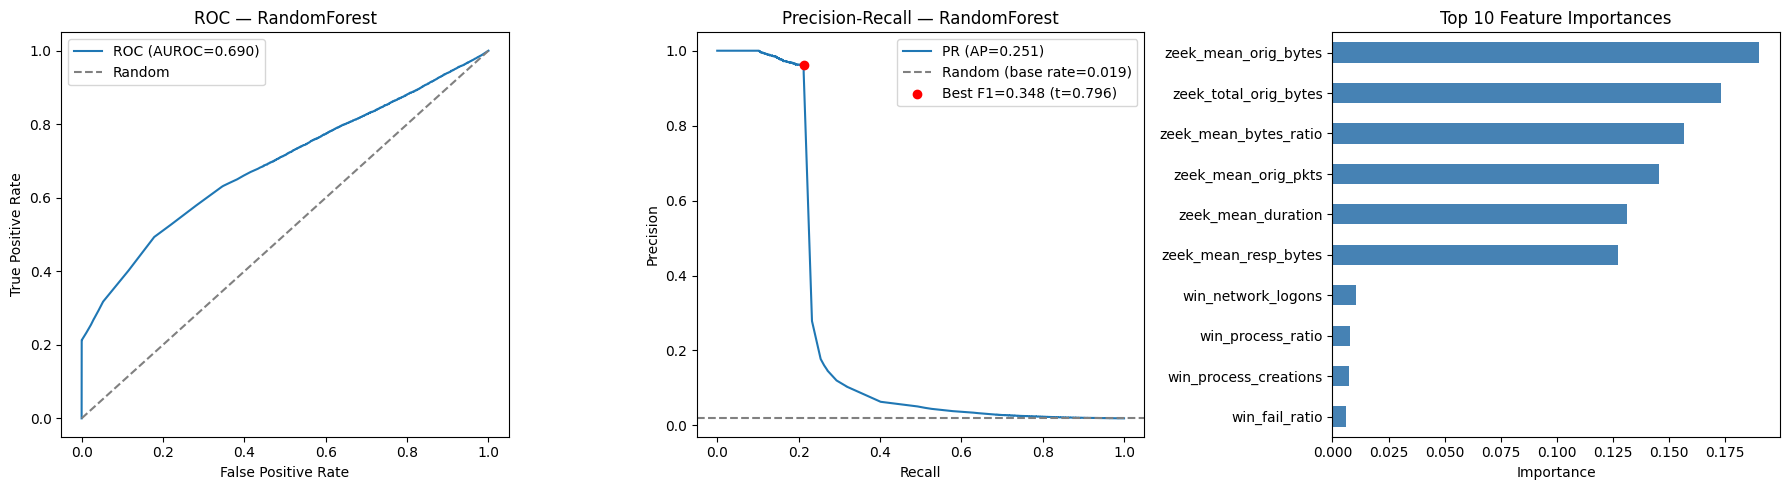


[6] Plots saved -> rf_evaluation_curves.png
[7] Full results saved -> rf_threat_results.csv

=== Done ===


In [22]:
# =============================================================================
# SUPERVISED RANDOM FOREST — PRIMARY MODEL
# =============================================================================
# RandomForest trained directly on the ground-truth labels.
#
# Run this AFTER building `combined`, `y_true`, `FEATURE_COLS` (from the
# session-aggregation + ground-truth cells earlier in the notebook).
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

RANDOM_STATE = 42
TEST_SIZE = 0.30

# -----------------------------------------------------------------------------
# 1. FEATURES & LABELS
# -----------------------------------------------------------------------------
X = combined[FEATURE_COLS].fillna(0)
y = y_true

print(f"[1] Feature matrix : {X.shape}")
print(f"    Positive rate  : {y.mean():.4%}  ({int(y.sum()):,} / {len(y):,} sessions)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"    Train : {X_train.shape}, positive rate {y_train.mean():.4%}")
print(f"    Test  : {X_test.shape}, positive rate {y_test.mean():.4%}")

# -----------------------------------------------------------------------------
# 2. TRAIN
# -----------------------------------------------------------------------------
print("\n[2] Training RandomForestClassifier...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",   # reweights loss for the minority class
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print("    Done.")

# -----------------------------------------------------------------------------
# 3. EVALUATE AT DEFAULT THRESHOLD (0.5)
# -----------------------------------------------------------------------------
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

auroc  = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
base_rate = y_test.mean()

print("\n[3] Metrics @ default threshold (0.5)")
print("-" * 60)
print(f"    AUROC     : {auroc:.4f}   (0.5 = random)")
print(f"    PR-AUC    : {pr_auc:.4f}   (random baseline = {base_rate:.4f}, "
      f"{pr_auc / base_rate:.1f}x random)")
print(f"    Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"    Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"    F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}")

print("\n    Confusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred))

print("\n    Classification report:")
print(classification_report(y_test, y_pred, target_names=["benign", "anomalous"], zero_division=0))

# -----------------------------------------------------------------------------
# 4. THRESHOLD TUNING — find the best operating point on the PR curve
# -----------------------------------------------------------------------------
print("\n[4] Threshold tuning via PR curve...")

precisions_arr, recalls_arr, thresholds_arr = precision_recall_curve(y_test, y_proba)
f1s = 2 * precisions_arr * recalls_arr / (precisions_arr + recalls_arr + 1e-12)
best_idx = np.argmax(f1s[:-1])
best_thresh, best_f1 = thresholds_arr[best_idx], f1s[best_idx]

y_pred_opt = (y_proba >= best_thresh).astype(int)
opt_precision = precision_score(y_test, y_pred_opt, zero_division=0)
opt_recall = recall_score(y_test, y_pred_opt, zero_division=0)

print(f"    Best-F1 threshold : {best_thresh:.3f}  (F1={best_f1:.4f}, "
      f"vs. {f1_score(y_test, y_pred, zero_division=0):.4f} @ 0.5)")
print(f"    At that threshold -> Precision={opt_precision:.4f}, Recall={opt_recall:.4f}")

# A couple of alternate operating points for the writeup: "high recall" and
# "high precision" modes, since a SOC tool often needs to pick a lane.
for target_recall in [0.7, 0.8, 0.9]:
    # find the lowest threshold that achieves at least this recall
    idx_candidates = np.where(recalls_arr >= target_recall)[0]
    if len(idx_candidates) == 0:
        continue
    idx = idx_candidates[-1]  # recalls_arr is decreasing as threshold increases; take smallest threshold hitting target
    thr = thresholds_arr[min(idx, len(thresholds_arr) - 1)]
    p_at_r = precisions_arr[idx]
    print(f"    @ recall>={target_recall:.0%}: threshold={thr:.3f}, precision={p_at_r:.4f}")

# -----------------------------------------------------------------------------
# 5. FEATURE IMPORTANCES
# -----------------------------------------------------------------------------
print("\n[5] Feature importances (top 15):")
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importances.head(15).to_string())

zeek_share = importances[[c for c in importances.index if c.startswith("zeek")]].sum()
win_share  = importances[[c for c in importances.index if c.startswith("win")]].sum()
print(f"\n    Total importance from Zeek features    : {zeek_share:.3f}")
print(f"    Total importance from Windows features : {win_share:.3f}")
print("    (Windows features contributing little suggests either weak signal in")
print("     those features, or the win_gt_anomaly_events label doesn't correlate")
print("     with observable host behavior — worth flagging as a limitation.)")

# -----------------------------------------------------------------------------
# 6. PLOTS — ROC, PR curve, feature importances
# -----------------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, label=f"ROC (AUROC={auroc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — RandomForest")
axes[0].legend()

axes[1].plot(recalls_arr, precisions_arr, label=f"PR (AP={pr_auc:.3f})")
axes[1].axhline(base_rate, linestyle="--", color="gray", label=f"Random (base rate={base_rate:.3f})")
axes[1].scatter([opt_recall], [opt_precision], color="red", zorder=5,
                label=f"Best F1={best_f1:.3f} (t={best_thresh:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — RandomForest")
axes[1].legend()

top_n = 10
importances.head(top_n)[::-1].plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title(f"Top {top_n} Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("rf_evaluation_curves.png", dpi=150)
plt.show()

print("\n[6] Plots saved -> rf_evaluation_curves.png")

# -----------------------------------------------------------------------------
# 7. SAVE PREDICTIONS FOR THE FULL DATASET (for the report / demo table)
# -----------------------------------------------------------------------------
combined["rf_threat_score"] = rf.predict_proba(X)[:, 1]
combined["rf_flag_default"] = (combined["rf_threat_score"] >= 0.5).astype(int)
combined["rf_flag_best_f1"] = (combined["rf_threat_score"] >= best_thresh).astype(int)

output_cols = [
    "source_ip", "win_session_start", "zeek_session_start",
    "rf_threat_score", "rf_flag_default", "rf_flag_best_f1",
    "zeek_gt_anomaly_conns", "win_gt_anomaly_events",
]
output_cols = [c for c in output_cols if c in combined.columns]

combined.sort_values("rf_threat_score", ascending=False)[output_cols].to_csv(
    "rf_threat_results.csv", index=False
)
print("[7] Full results saved -> rf_threat_results.csv")

print("\n=== Done ===")